In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/Cinema_Audience_Forecasting_challenge/movie_theater_id_relation/movie_theater_id_relation.csv
/kaggle/input/Cinema_Audience_Forecasting_challenge/date_info/date_info.csv
/kaggle/input/Cinema_Audience_Forecasting_challenge/sample_submission/sample_submission.csv
/kaggle/input/Cinema_Audience_Forecasting_challenge/booknow_theaters/booknow_theaters.csv
/kaggle/input/Cinema_Audience_Forecasting_challenge/cinePOS_booking/cinePOS_booking.csv
/kaggle/input/Cinema_Audience_Forecasting_challenge/cinePOS_theaters/cinePOS_theaters.csv
/kaggle/input/Cinema_Audience_Forecasting_challenge/booknow_visits/booknow_visits.csv
/kaggle/input/Cinema_Audience_Forecasting_challenge/booknow_booking/booknow_booking.csv


# Cinema Audience Forecasting challenge



* This notebook addresses the cinema audience forecasting challenge. It is a time series forecasting problem.* The goal is to    predict daily theatre audience counts across multiple locations.
* The prediction depends on the data from two distinct booking sources:
  a) BookNow- Online booking and aggregation platform.     b) CinePOS- A point-of-sale (POS) system installed at the theatres.
* Features like weekends, theatre type and booking trends are key predictors.

# 1. Initial Setup and Data Loading

* This section imports all the necessary libraries like--
* pandas & numpy: For data manipulation and numerical operations
* sklearn: For preprocessing, modeling, and evaluation
* lightgbm & xgboost: For gradient boosting models
* matplotlib & seaborn: For visualizations 

In [2]:
import numpy as np
import pandas as pd
import datetime
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
%matplotlib inline

from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder, RobustScaler
from sklearn.feature_selection import mutual_info_regression, f_regression
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
import xgboost as xgb
from xgboost import XGBRegressor
import lightgbm as lgb
from lightgbm import LGBMRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns',None)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize']=[14,8]

* Data Loading- This section reads all raw data files into Pandas DataFrames.

In [3]:
booknow_visits=pd.read_csv('/kaggle/input/Cinema_Audience_Forecasting_challenge/booknow_visits/booknow_visits.csv')
booknow_theaters=pd.read_csv('/kaggle/input/Cinema_Audience_Forecasting_challenge/booknow_theaters/booknow_theaters.csv')
date_info=pd.read_csv('/kaggle/input/Cinema_Audience_Forecasting_challenge/date_info/date_info.csv')
booknow_booking=pd.read_csv('/kaggle/input/Cinema_Audience_Forecasting_challenge/booknow_booking/booknow_booking.csv')
cinePOS_booking=pd.read_csv('/kaggle/input/Cinema_Audience_Forecasting_challenge/cinePOS_booking/cinePOS_booking.csv')
cinePOS_theaters=pd.read_csv('/kaggle/input/Cinema_Audience_Forecasting_challenge/cinePOS_theaters/cinePOS_theaters.csv')
relation=pd.read_csv('/kaggle/input/Cinema_Audience_Forecasting_challenge/movie_theater_id_relation/movie_theater_id_relation.csv')

sample_submission=pd.read_csv("/kaggle/input/Cinema_Audience_Forecasting_challenge/sample_submission/sample_submission.csv")

# 2. EDA Part 1- Raw Files Analysis

Exploratory Data Analysis is the initial process of investigating and summarizing datasets to understand their main characteristics. It is performed by using visual methods and descriptive statistics.

In [4]:
def summarize_df(df, name):
    
    print(f'Summary for: {name}')
   
    print(f'Shape: {df.shape[0]:,} rows x {df.shape[1]} columns')
    print(f'Duplicates: {df.duplicated().sum():,}')

    summary= pd.DataFrame({
        'Data Type' : df.dtypes,
        'Non Null'  : df.count(),
        'Missing %' : (df.isnull().sum()/len(df) *100).round(2),
        'Unique'    : df.nunique()
    })
    
    print("\n"+ summary.sort_values('Missing %', ascending=False).to_string())
    print("\n" + df.describe().T.round(2).to_string())

The function "summarize_df" is the first step for EDA. It generates following key insights about the datasets.

1. Shape of the DataFrame using .shape attribute. 
2. Duplicates
3. Concise summary of the DataFrame using .info() method.
4. Missing Value Percentage.
5. Descriptive Statistics using .describe().

In [5]:
summarize_df(booknow_visits, "booknow_visits")

Summary for: booknow_visits
Shape: 214,046 rows x 3 columns
Duplicates: 10

                Data Type  Non Null  Missing %  Unique
book_theater_id    object    214046        0.0     826
show_date          object    214046        0.0     424
audience_count      int64    214046        0.0     191

                   count   mean    std  min   25%   50%   75%     max
audience_count  214046.0  41.62  32.83  2.0  18.0  34.0  58.0  1350.0


* Dataset Size- The file contains 214046 records and 3 columns.
* Duplicates- The file contains 10 duplicate values.
* Missing Values- There are zero missing values.
* The "show_date" column is in string format which needs to be converted into datetime object.
* Target variable is "audience_count".

In [6]:
summarize_df(booknow_theaters, "booknow_theaters")

Summary for: booknow_theaters
Shape: 829 rows x 5 columns
Duplicates: 354

                Data Type  Non Null  Missing %  Unique
book_theater_id    object       314      62.12     314
theater_type       object       829       0.00       4
theater_area       object       829       0.00     103
latitude          float64       829       0.00     108
longitude         float64       829       0.00     108

           count  mean   std    min    25%    50%    75%    max
latitude   829.0  23.0  0.83  22.03  22.62  23.00  23.02  26.35
longitude  829.0  79.0  1.46  76.11  78.17  79.91  79.93  81.74


* Shape: The dataset contains 829 rows and 5 columns.
* Missing Values: 62.12% of the "book_theater_id" column is missing. These values needs to be dropped.

In [7]:
summarize_df(date_info, "date_info")

Summary for: date_info
Shape: 547 rows x 2 columns
Duplicates: 0

            Data Type  Non Null  Missing %  Unique
show_date      object       547        0.0     547
day_of_week    object       547        0.0       7

            count unique         top freq
show_date     547    547  2023-01-01    1
day_of_week   547      7      Sunday   79


* Shape- This dataset contains 547 rows and 2 columns.
* Missing Values- There are no missing values in this dataset.
* Duplicates- There are no duplicates in this dataset.
* "show_date" column is stored as an object and needs to be changed into datetime Dtype.
* "day_of_week" column is a strong predictor with expected 7 unique values.

In [8]:
summarize_df(booknow_booking, 'booknow_booking')

Summary for: booknow_booking
Shape: 68,336 rows x 4 columns
Duplicates: 2,042

                 Data Type  Non Null  Missing %  Unique
book_theater_id     object     68336        0.0     301
show_datetime       object     68336        0.0    3866
booking_datetime    object     68336        0.0    6351
tickets_booked       int64     68336        0.0      66

                  count  mean   std  min  25%  50%  75%    max
tickets_booked  68336.0  4.43  4.81  1.0  2.0  3.0  5.0  100.0


* Shape- This dataset contains 68336 booking records with 4 columns.
* Missing Values- This dataset contains zero missing values.
* Dulicates- There are 2042 duplicate rows.
* Both "show_datetime" and "booking_datetime" is stored as an object Dtype and needs to be converted into a datetime Dtype.

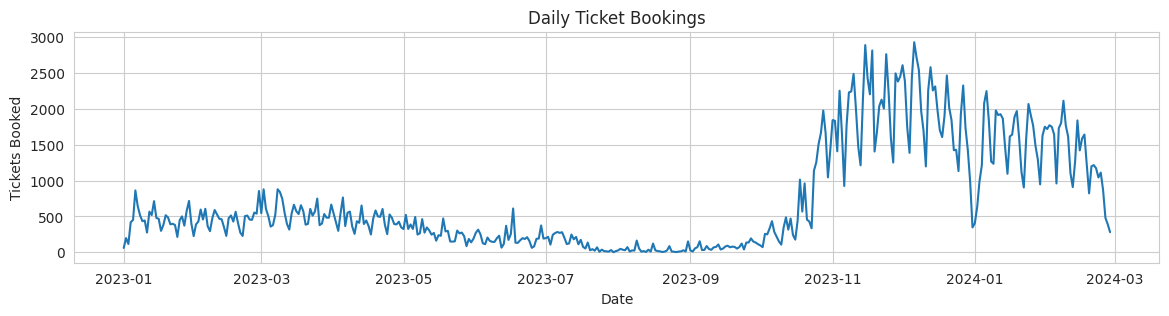

In [9]:
bookings = booknow_booking.copy()
bookings['booking_datetime'] = pd.to_datetime(bookings['booking_datetime'])

daily_tickets = bookings.set_index('booking_datetime').resample('D')['tickets_booked'].sum()

plt.figure(figsize=(14, 3))
plt.plot(daily_tickets.index, daily_tickets.values)
plt.title("Daily Ticket Bookings")
plt.xlabel("Date")
plt.ylabel("Tickets Booked")
plt.show()

* Total Tickets booked stays stable for most of 2023, with small fluctuations.
* A sharp surge begins around October 2023. Where daily bookings rises dramatically.
* This late-year spike suggests a seasonal effect or major event period driving much higher ticket demand.

In [10]:
summarize_df(cinePOS_booking, "cinePOS_booking")

Summary for: cinePOS_booking
Shape: 1,641,966 rows x 4 columns
Duplicates: 12,541

                 Data Type  Non Null  Missing %  Unique
cine_theater_id     object   1641966        0.0   13161
show_datetime       object   1641966        0.0    8283
booking_datetime    object   1641966        0.0   10152
tickets_sold         int64   1641966        0.0      97

                  count  mean   std  min  25%  50%  75%    max
tickets_sold  1641966.0  4.99  5.23  1.0  2.0  3.0  6.0  100.0


* Shape- Its a huge dataset with 1641966 rows and 4 columns.
* Missing Values- There are no missing values in this dataset.
* Duplicates- There are 12,541 duplicate rows.
* Both "show_datetime" and "booking_datetime" are stored as an object Dtype.
* "cine_theater_id" needs to be mapped with "book_theater_id" using the relation file.

In [11]:
summarize_df(cinePOS_theaters, "cinePOS_theaters")

Summary for: cinePOS_theaters
Shape: 4,690 rows x 5 columns
Duplicates: 0

                Data Type  Non Null  Missing %  Unique
latitude          float64       829      82.32     108
longitude         float64       829      82.32     108
cine_theater_id    object      4690       0.00    4690
theater_type       object      4690       0.00       3
theater_area       object      4690       0.00     119

           count  mean   std    min    25%    50%    75%    max
latitude   829.0  23.0  0.83  22.03  22.62  23.00  23.02  26.35
longitude  829.0  79.0  1.46  76.11  78.17  79.91  79.93  81.74


* Shape- This dataset contains 4690 rows and 5 columns.
* Missing Values- Both "latitude" and "longitude" have more than 82% missing values.
* Duplicates- No duplicate rows.

# 3. Data Merging

In [12]:
booknow_visits.drop_duplicates(inplace=True)
booknow_theaters.dropna(subset=['book_theater_id'], inplace=True)
booknow_theaters.drop_duplicates(inplace=True)
booknow_booking.drop_duplicates(inplace=True)
cinePOS_booking.drop_duplicates(inplace=True)

* This code block ensures that the base data files are clean before merging. Data cleaning is critical because poor data quality    leads to unreliable predictions.
* Used drop_duplicates() to remove exact copies.
* Used dropna(subset=['book_theater_id'] to remove rows without valid IDs from booknow_theaters.

In [13]:
base = pd.merge(booknow_visits, booknow_theaters, on='book_theater_id', how='left')

base['show_date'] = pd.to_datetime(base['show_date'], errors = 'coerce')
date_info['show_date'] = pd.to_datetime(date_info['show_date'], errors = 'coerce')

base=pd.merge(base, date_info, on='show_date', how='left')

* Here, a base dataset is created to which other datasets will be merged.
* First step was to merge booknow_visits (which contains the target variable "audience_count") with booknow_theaters using       "book_theater_id". Used left join to keep all visit records (our target variable is here
* In the next step, "show_date" was converted into datetime format, which was essential for time analysis.
*  Used left join again to keep all our base record.

In [14]:
booknow_booking['show_datetime'] = pd.to_datetime(booknow_booking['show_datetime'], errors='coerce')
booknow_booking['booking_datetime'] = pd.to_datetime(booknow_booking['booking_datetime'], errors='coerce')

booknow_booking['days_in_advance'] = (
    (booknow_booking['show_datetime'].dt.floor('D') - 
     booknow_booking['booking_datetime'].dt.floor('D')).dt.days.clip(0)
)

online = booknow_booking.groupby(['book_theater_id', booknow_booking['show_datetime'].dt.date]).agg({
    'tickets_booked': 'sum',
    'booking_datetime': 'count',
    'days_in_advance': 'mean'
}).reset_index()

online.columns = ['book_theater_id', 'show_date', 'online_tickets_sum', 'online_booking_count', 'online_avg_days_advance']
online['show_date'] = pd.to_datetime(online['show_date'])

base = pd.merge(base, online, on=['book_theater_id', 'show_date'], how='left')

* Converted both 'show_datetime' and 'booking_datetime' into datetime object to allow time calculations.
*  'days_in_advance' was calculated which is gap between the show date and the booking date. Early booking indicates anticipated popular show.
*  All online transactions were aggregated by 'book_theater_id' and 'show_date. Three key features were calculated-
  a) 'online_tickets_sum'- Total Tickets booked online.
  b) 'online_booking_count'- Count of how many individual bookings occured.
  c) 'online_avg_days_advance'- Average booking lead time.  Higher values indicate strong advance interest and lower values       suggest spontaneous decisions.
*  These features were merged into base dataset using 'book_theater_id' and 'show_date' as common keys using left join.

In [15]:
cinePOS_booking['show_datetime'] = pd.to_datetime(cinePOS_booking['show_datetime'], errors='coerce')
cinePOS_booking['show_date'] = cinePOS_booking['show_datetime'].dt.date

onsite=cinePOS_booking.groupby(['cine_theater_id', 'show_date']).agg({
    'tickets_sold':'sum',
    'booking_datetime':'count'
}).reset_index()

onsite.columns = ['cine_theater_id','show_date','onsite_tickets_sum','onsite_sales_count']
onsite = pd.merge(onsite, relation, on='cine_theater_id', how='left')
onsite['show_date']=pd.to_datetime(onsite['show_date'])

base=pd.merge(base, onsite[['book_theater_id', 'show_date','onsite_tickets_sum','onsite_sales_count']], 
              on=['book_theater_id','show_date'], how='left')

booking_columns=['online_tickets_sum', 'online_booking_count', 'online_avg_days_advance','onsite_tickets_sum', 'onsite_sales_count']

base[booking_columns]=base[booking_columns].fillna(0)

print(f"\nBase Data Shape: {base.shape}")


Base Data Shape: (214036, 13)


*  All onsite transactions were aggregated using 'cine_theater_id' and 'show_date' to calculate two new features-
   a) 'onsite_tickets_sum'- Total walk-in tickets sold. It captures spontaneous audience behaviour.
   b) 'onsite_sales_count'.-  Number of counter transactions. It shows foot traffic at the venue.
*  It then maps the 'cine_theater_id' to the 'book_theater_id' using the relation file. This allows us to merge POS data with booking platform data.
*  The aggregated and mapped features were merged into the base dataset.

# 4. Feature Engineering Function

In [16]:
def date_and_lag_features(df):
    df['total_tickets_booked'] = df['online_tickets_sum'] + df['onsite_tickets_sum']
    df = df.sort_values(['book_theater_id', 'show_date']).reset_index(drop=True)
    
    df['day_of_week'] = df['show_date'].dt.dayofweek
    df['Weekend'] = (df['day_of_week'] >= 5).astype(int)
    df['Month'] = df['show_date'].dt.month
    df['week_of_year'] = df['show_date'].dt.isocalendar().week.astype(int)
    df['quarter'] = df['show_date'].dt.quarter
    df['day_of_year'] = df['show_date'].dt.dayofyear
    
    gb = df.groupby('book_theater_id')['audience_count']
    for lag in [1, 2, 3, 4, 5, 6, 7, 14, 21, 28, 35, 42]:
        df[f'lag_{lag}'] = gb.shift(lag)
    
    df['roll_mean_7'] = gb.transform(lambda x: x.shift(1).rolling(7, min_periods=1).mean())
    df['roll_mean_14'] = gb.transform(lambda x: x.shift(1).rolling(14, min_periods=1).mean())
    df['expanding_mean'] = gb.transform(lambda x: x.shift(1).expanding(min_periods=1).mean())
    
    df['volatility'] = gb.transform(lambda x: x.shift(1).rolling(7, min_periods=1).std())
    df['ewma_7'] = gb.transform(lambda x: x.shift(1).ewm(span=7, adjust=False).mean())
    
    return df

base= date_and_lag_features(base)

* Sorted by firstly theater and then date within each theater.
* Basic temporal features were generated-
  a) Day of Week- Returns 0=Monday, 1=Tuesday,and upto 6=Sunday.
  b) Weekend- Binary feature: 1 if Saturday/Sunday, 0 otherwise.
  c) Month- Returns 1-12.
  d) Week of Year- Return 1-52.
  e) Day of Year- Returen 1-365.
* Lag features- For historical counts. Like:
  a)lag_7: Audience count from exactly 7 days ago.
  b)lag_14: Audience count from 14 days ago.
  c)lag_28: Audience count from 28 days ago (4 weeks).

* Rolling Statistics( Moving Averages)
  a) roll_mean_7:  Average audience over past week.
  b) roll_mean_14: Average audience over past two weeks.
* Expanding Mean:  Instead of a fixed window, it uses all previous history. Each theater has different capacity and popularity.
  It represents the theater's baseline performance.
* Momentum: It is a ratio of short-term average to medium-term average.
* Volatility: It is a standard deviation of audience counts over past 7 days.
* Exponentially Weighted Moving Average (EWMA): It gives more weight to recent days.

# 5. Exploratory Data Analysis- Part 2

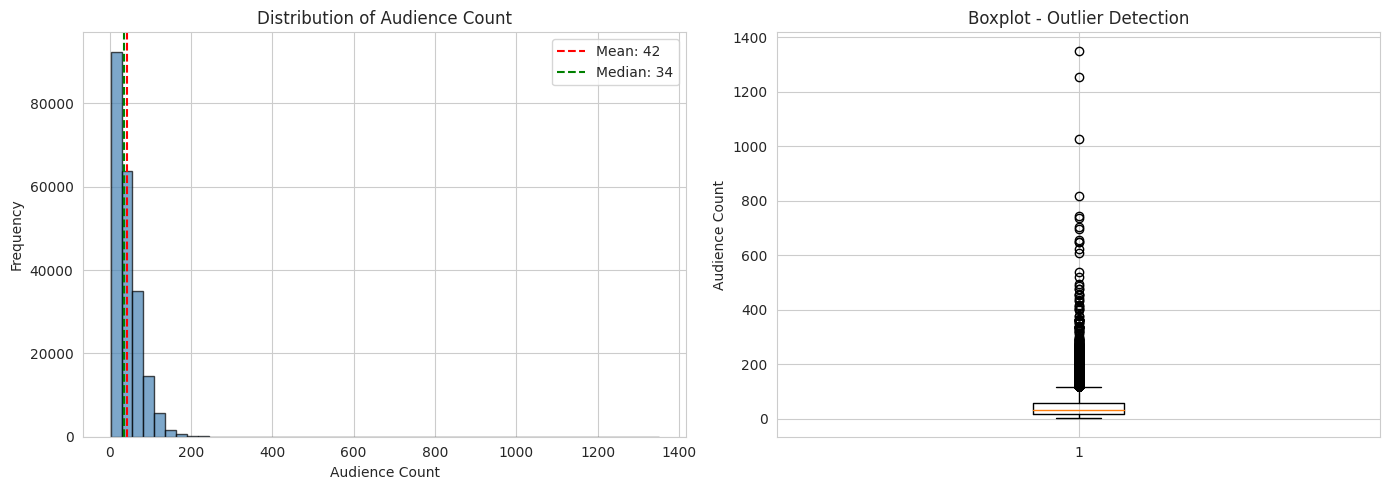

In [17]:
# Target Varible Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(base['audience_count'], bins=50, alpha=0.7, color='steelblue', edgecolor='black')
axes[0].set_xlabel('Audience Count')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Audience Count')
axes[0].axvline(base['audience_count'].mean(), color='red', linestyle='--', label=f'Mean: {base["audience_count"].mean():.0f}')
axes[0].axvline(base['audience_count'].median(), color='green', linestyle='--', label=f'Median: {base["audience_count"].median():.0f}')
axes[0].legend()

axes[1].boxplot(base['audience_count'])
axes[1].set_ylabel('Audience Count')
axes[1].set_title('Boxplot - Outlier Detection')

plt.tight_layout()
plt.show()

* The audience count is highly right-skewed where most shows attrac low to moderate audiences.
* A small number of shows have very large audiences. This indicates presence of extreme outliers.
* The mean is higher than the median because of these few high-value outliers.

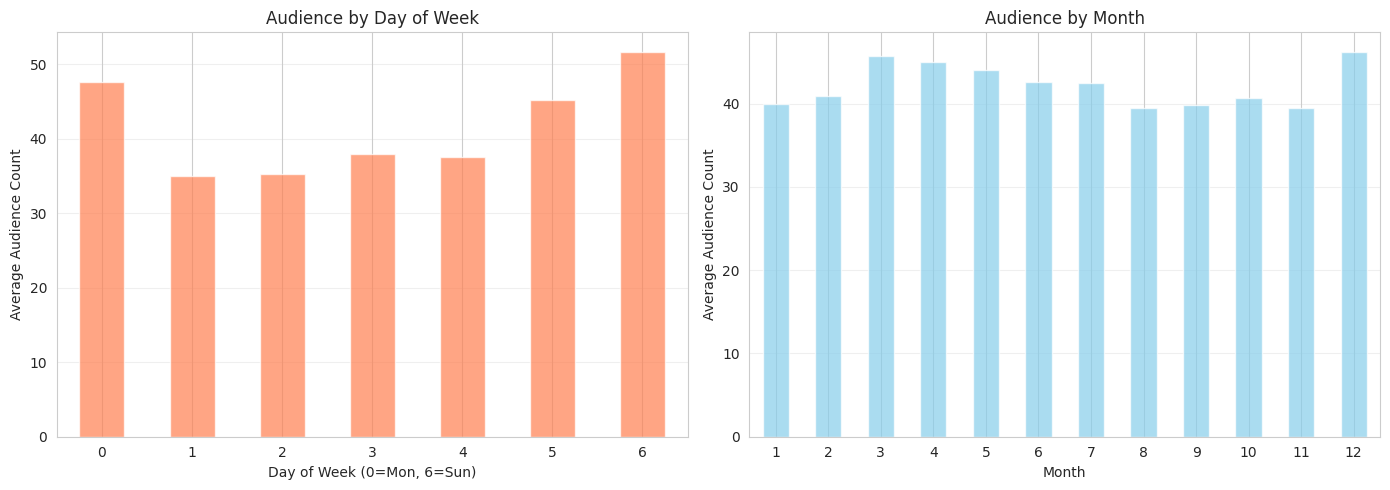

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Day of week pattern
base.groupby('day_of_week')['audience_count'].mean().plot(kind='bar', ax=axes[0], color='coral', alpha=0.7)
axes[0].set_xlabel('Day of Week (0=Mon, 6=Sun)')
axes[0].set_ylabel('Average Audience Count')
axes[0].set_title('Audience by Day of Week')
axes[0].tick_params(axis='x', rotation=0)
axes[0].grid(axis='y', alpha=0.3)

# Month pattern
base.groupby('Month')['audience_count'].mean().plot(kind='bar', ax=axes[1], color='skyblue', alpha=0.7)
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Average Audience Count')
axes[1].set_title('Audience by Month')
axes[1].tick_params(axis='x', rotation=0)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

* Average audience count is highest on Sundays and Mondays and lowest on Tuesdays and Wednesdays.
* Average audience count is highest on December and March. Overall monthly engagement remains steady throughout. 

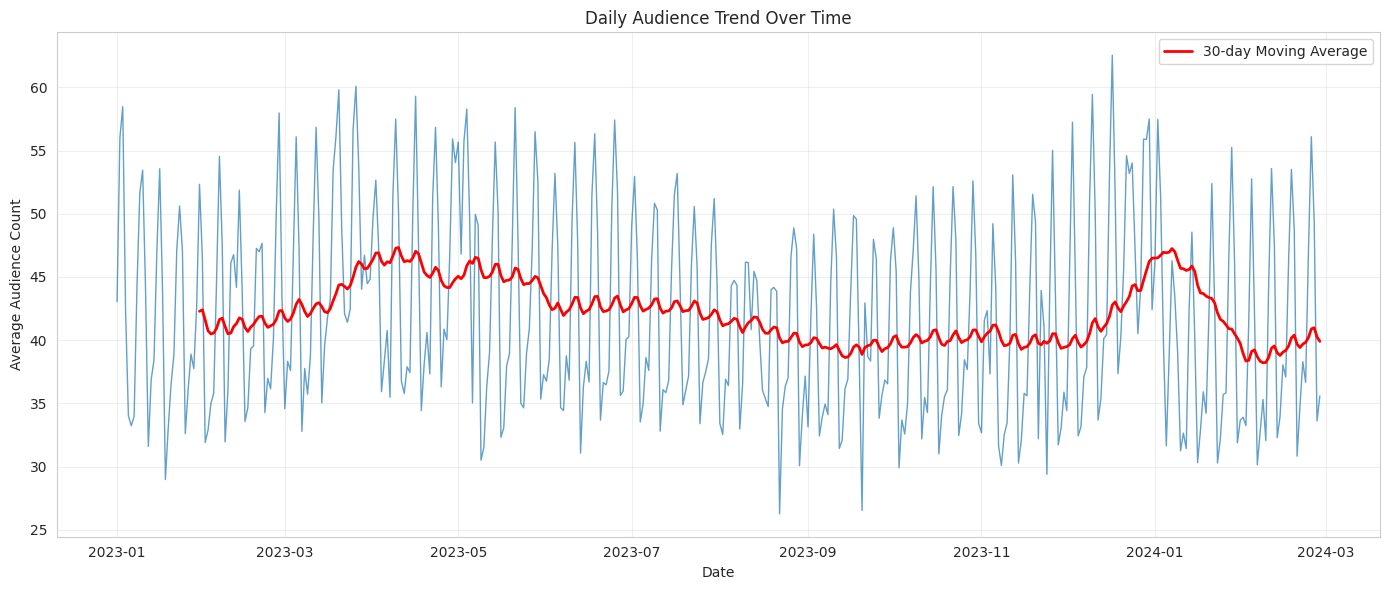

In [19]:
plt.figure(figsize=(14, 6))
daily_avg = base.groupby('show_date')['audience_count'].mean()
plt.plot(daily_avg.index, daily_avg.values, alpha=0.7, linewidth=1)
plt.plot(daily_avg.rolling(30).mean(), color='red', linewidth=2, label='30-day Moving Average')
plt.xlabel('Date')
plt.ylabel('Average Audience Count')
plt.title('Daily Audience Trend Over Time')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

* Daily audience count fluctuates heaviliy whereas long term trends appear stable.
* Audience level peak can be seen around early 2023 and early 2024 and slight dip can be seen around mid 2023.

In [20]:
y_ = base['audience_count']
X_ = base.drop(['audience_count', 'show_date', 'book_theater_id'], axis=1)
X_['theater_type'] = LabelEncoder().fit_transform(X_['theater_type'].fillna('missing'))
X_['theater_area'] = LabelEncoder().fit_transform(X_['theater_area'].fillna('missing'))
X_ = X_.fillna(X_.median())
mi = mutual_info_regression(X_, y_, random_state=42)
pd.DataFrame({'Feature': X_.columns, 'MI_Score': mi}).sort_values('MI_Score', ascending=False)

,Feature,MI_Score
29,roll_mean_14,0.331813
28,roll_mean_7,0.323429
30,expanding_mean,0.318345
32,ewma_7,0.302982
21,lag_6,0.219183
22,lag_7,0.216782
16,lag_1,0.196430
23,lag_14,0.176138
24,lag_21,0.160828
20,lag_5,0.158738


* Rolling averages (7-day, 14-day) and lag features (1-42 days) are the strongest predictors.
* Geographic attributes and calendar features contribute negligibly.

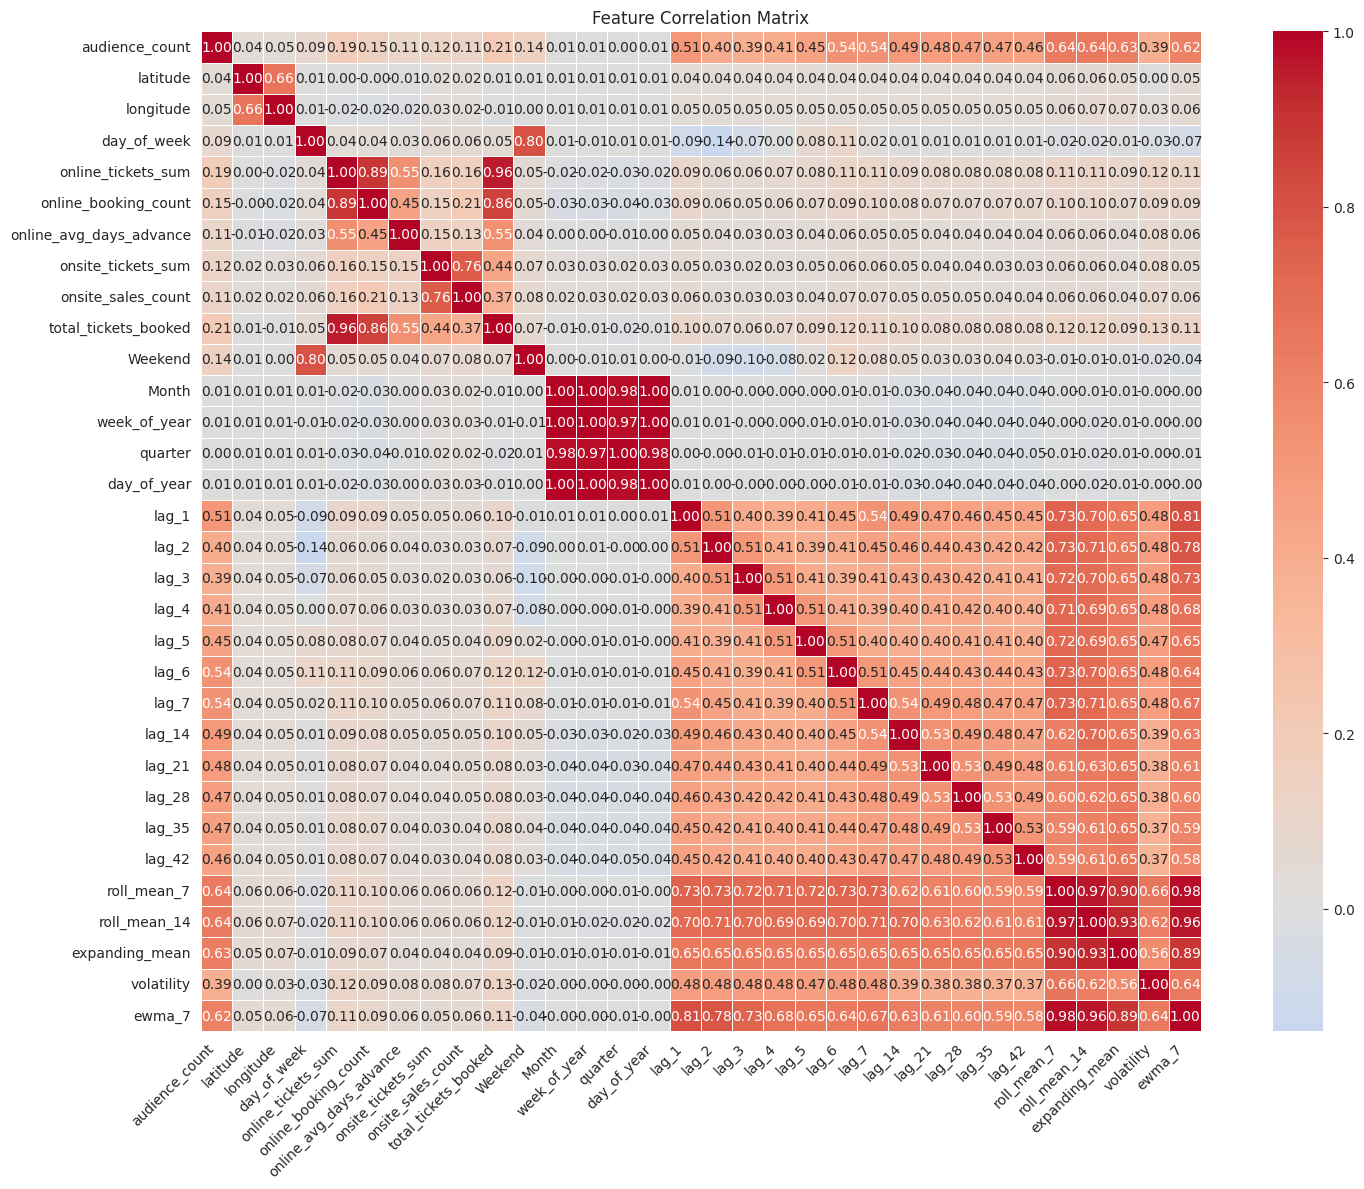


Top correlations with audience_count:
audience_count    1.000000
roll_mean_14      0.643898
roll_mean_7       0.636118
expanding_mean    0.627888
ewma_7            0.616193
lag_7             0.536379
lag_6             0.536138
lag_1             0.511550
lag_14            0.494441
lag_21            0.477566
Name: audience_count, dtype: float64


In [21]:
numeric_cols = base.select_dtypes(include='number').columns
corr_matrix = base[numeric_cols].corr()

plt.figure(figsize=(16, 12))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=0.5)
plt.title('Feature Correlation Matrix')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("\nTop correlations with audience_count:")
target_corr = corr_matrix['audience_count'].abs().sort_values(ascending=False)
print(target_corr.head(10))

* Audience count is influenced by features like dow_theater_avg, weekend_theater_avg and theater_avg.
* Rolling features and lag features also correlate well.
* Whereas, calendar features show minimum correlation.

In [22]:
corr_matrix = X_.corr().abs()

upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr = [(col, row, upper.loc[row, col]) 
             for col in upper.columns 
             for row in upper.index 
             if upper.loc[row, col] > 0.9]

print("Highly Correlated Pairs (>0.9):")
for f1, f2, val in high_corr:
    print(f"{f1:30s}  {f2:30s}  {val:.4f}")

Highly Correlated Pairs (>0.9):
total_tickets_booked            online_tickets_sum              0.9568
week_of_year                    Month                           0.9959
quarter                         Month                           0.9781
quarter                         week_of_year                    0.9747
day_of_year                     Month                           0.9971
day_of_year                     week_of_year                    0.9987
day_of_year                     quarter                         0.9757
roll_mean_14                    roll_mean_7                     0.9684
expanding_mean                  roll_mean_14                    0.9301
ewma_7                          roll_mean_7                     0.9778
ewma_7                          roll_mean_14                    0.9613


* Calendar features are redundant as Day_of_year, week_of_year, month, and quarter are 97-99% correlated.
* 7-day and 14-day rolling means and EWMA feature are capturing similar trends.
* The high correlation between total_tickets_booked and online_tickets_sum indicates online sales dominates bookings.

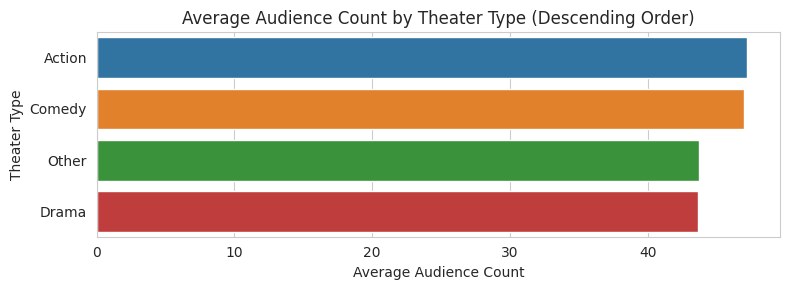

In [23]:
plt.figure(figsize=(8, 3))
sns.barplot(
    data=base,
    y='theater_type',
    x='audience_count',
    estimator=np.mean, 
    errorbar=None,
    order=base.groupby('theater_type')['audience_count'].mean().sort_values(ascending=False).index
)
plt.title("Average Audience Count by Theater Type (Descending Order)")
plt.xlabel("Average Audience Count")
plt.ylabel("Theater Type")
plt.tight_layout()
plt.show()

* Comedy and Action theaters have the highest average audience. Whereas, Drama and Other categories have lower average audience comparatively.

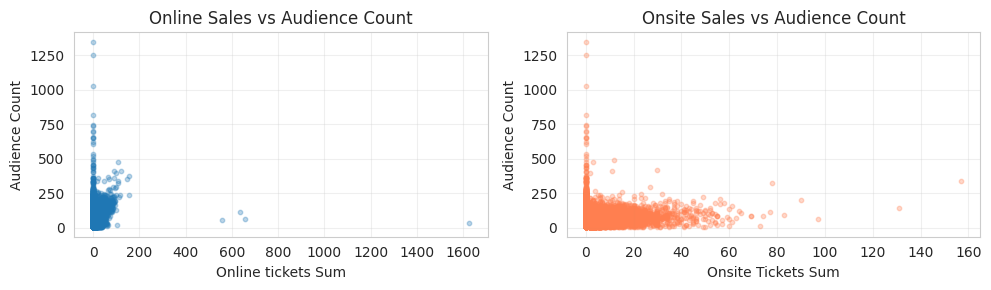

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3))

# Online sales impact
axes[0].scatter(base['online_tickets_sum'], base['audience_count'], alpha=0.3, s=10)
axes[0].set_xlabel('Online tickets Sum')
axes[0].set_ylabel('Audience Count')
axes[0].set_title('Online Sales vs Audience Count')
axes[0].grid(alpha=0.3)

# Onsite sales impact
axes[1].scatter(base['onsite_tickets_sum'], base['audience_count'], alpha=0.3, s=10, color='coral')
axes[1].set_xlabel('Onsite Tickets Sum')
axes[1].set_ylabel('Audience Count')
axes[1].set_title('Onsite Sales vs Audience Count')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

* Both online_tickets_sum and onsite_tickets_sum have a positive but weak correlation with target.
* Most days have low to medium sales with few days with high audience numbers.
* Both online and onsite bookings show a very few large outliers. It indicates occasional events that draw big crowds.

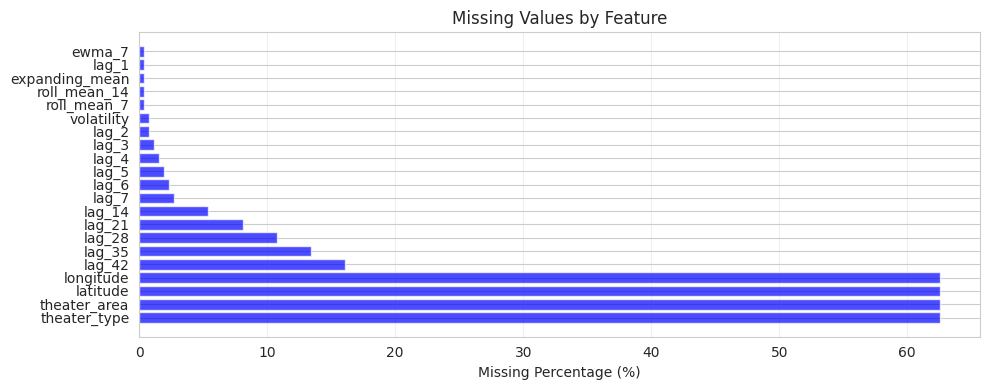

In [25]:
missing = base.isnull().sum()
missing_pct = (missing / len(base) * 100).round(2)
missing_df = pd.DataFrame({
    'Feature': missing.index,
    'Missing Count': missing.values,
    'Missing %': missing_pct.values
}).sort_values('Missing %', ascending=False)


missing_features = missing_df[missing_df['Missing %'] > 0]

if len(missing_features) > 0:
    plt.figure(figsize=(10, 4))
    plt.barh(missing_features['Feature'], missing_features['Missing %'], color='blue', alpha=0.7)
    plt.xlabel('Missing Percentage (%)')
    plt.title('Missing Values by Feature')
    plt.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print(" No missing values found in the dataset!")

* Theater related features have highest missing values.
* Lag features show moderate missingness.
* Rolling features have least missing values.

In [26]:
theaters_with_coords = base[base['latitude'].notna()].groupby('book_theater_id').agg({
    'latitude': 'first',
    'longitude': 'first',
    'audience_count': 'mean',
    'theater_type': 'first'
}).reset_index()

fig = px.scatter_mapbox(
    theaters_with_coords,
    lat='latitude',
    lon='longitude',
    color='theater_type',
    size='audience_count',
    hover_name='book_theater_id',
    hover_data={'audience_count': ':.0f'},
    title='Theater Locations (Size = Avg Audience)',
    zoom=4,
    height=600
)
fig.update_layout(mapbox_style='open-street-map')
fig.write_html('theater_map.html')
fig.show()

* Theaters are clustered mainly around central India.
* Only a few theaters appear in the northern region.

# 6. Preprocessing Pipeline

In [27]:
drop_features=[

    'theater_type', 'Month', 'week_of_year',
    'quarter', 'roll_mean_7', 'ewma_7', 'expanding_mean',
    'online_tickets_sum', 'theater_area', 'latitude', 'longitude'
]

base= base.drop(columns=drop_features)

In [28]:
le = LabelEncoder()
base['theater_encoded'] = le.fit_transform(base['book_theater_id'])

num_features = [
    'theater_encoded', 
    'lag_1', 'lag_2', 'lag_3', 'lag_7', 'lag_14', 'lag_21', 'lag_28',
    'roll_mean_14',
    'day_of_week', 'day_of_year',
    'online_booking_count', 'online_avg_days_advance', 
    'onsite_tickets_sum', 'onsite_sales_count', 'total_tickets_booked',
    'volatility'
]

binary_features = ['Weekend']
all_features = num_features + binary_features

preprocessor = ColumnTransformer([
    ('num', Pipeline([
        ('impute', SimpleImputer(strategy='median')),
        ('scale', RobustScaler())
    ]), num_features),
    ('binary', Pipeline([
        ('impute', SimpleImputer(strategy='constant', fill_value=0))
    ]), binary_features)
], remainder='drop')

* Feature Grouping- Features are grouped into groups:  Binary and Numerical.
*  For Numerical columns missing values are imputed with the median, since median is robust to outliers and features are scaled using RobustScaler to reduce the impact of outliers. RobustScaler uses median and IQR.
*  For Binary columns Missing values are filled with a constant (0).

In [29]:
data = (base
        .sort_values('show_date')
        .dropna(subset=['lag_42'])
        .reset_index(drop=True))

X = data.drop(columns=['audience_count'])
y = data['audience_count']

print(f"\nDataset: {len(data):,} samples, {X.shape[1]} features")
print(f"Date range: {data['show_date'].min().date()} to {data['show_date'].max().date()}")
print(f"Target mean: {y.mean():.1f}, std: {y.std():.1f}")


Dataset: 179,551 samples, 25 features
Date range: 2023-02-12 to 2024-02-28
Target mean: 41.6, std: 32.6


* Data is sorted by show_date because time series data must be in chronological order. It ensures earlier data comes before later data.
* lag_42 looks back 42 days that's why first 42 days of data have no 42-day history. Hence, Initial rows missing a value for the largest lag feature (lag_42) are dropped.

# 7.  Model Define

In [30]:
models = {
    'LightGBM': LGBMRegressor(n_estimators=1000, learning_rate=0.05, max_depth=7, random_state=42, n_jobs=-1, verbose=-1),
    'XGBoost': XGBRegressor(n_estimators=1000, learning_rate=0.05, max_depth=6, random_state=42, n_jobs=-1, verbosity=0),
    'RandomForest': RandomForestRegressor(n_estimators=200, max_depth=15, random_state=42, n_jobs=-1),
    'GradientBoosting': GradientBoostingRegressor(n_estimators=200, learning_rate=0.05, max_depth=6, random_state=42)
}

* Four different ensemble algorithms to find the best performer-
* A) LightGBM (Light Gradient Boosting Machine)- It is knwon for fast training speed, efficient memory usage and is excellent for large datasets.
* B) XGBoost( Extreme Gradient Boosting)- XGBoost is a robust, industry-standard Gradient Boosting machine.
* C) Random Forest- It is a classic ensemble model that is less prone to overfitting.
* D) Gradient Boosting- It is used as a powerful baseline comparison.

# 8. Time Series Cross Validation

In [31]:
# TimeSeriesSplit
tscv = TimeSeriesSplit(n_splits=3)
results = {name: {'r2': [], 'rmse': [], 'mae': []} for name in models}  # Removed MSE

for fold, (train_idx, val_idx) in enumerate(tscv.split(X), 1):
    print(f"\nFold {fold}/3")
    
    X_train = preprocessor.fit_transform(
        X.iloc[train_idx].drop(columns=['show_date', 'book_theater_id'])
    )
    X_val = preprocessor.transform(
        X.iloc[val_idx].drop(columns=['show_date', 'book_theater_id'])
    )
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
    
    for name, model in models.items():
      
        if name in ['LightGBM', 'XGBoost']:
            if name == 'LightGBM':
                model.fit(X_train, y_train, 
                         eval_set=[(X_val, y_val)],
                         callbacks=[lgb.early_stopping(50, verbose=False)])
            else: 
                model.fit(X_train, y_train,
                         eval_set=[(X_val, y_val)],
                         early_stopping_rounds=50,
                         verbose=False)
        else:
            model.fit(X_train, y_train)
       
        y_pred = model.predict(X_val).clip(0)
        r2 = r2_score(y_val, y_pred)
        rmse = np.sqrt(mean_squared_error(y_val, y_pred))
        mae = mean_absolute_error(y_val, y_pred)
        
        results[name]['r2'].append(r2)
        results[name]['rmse'].append(rmse)
        results[name]['mae'].append(mae)
        
        print(f"{name:15} R²={r2:.4f}  RMSE={rmse:.2f}  MAE={mae:.2f}")


Fold 1/3
LightGBM        R²=0.4790  RMSE=22.57  MAE=14.99
XGBoost         R²=0.4232  RMSE=23.74  MAE=16.03
RandomForest    R²=0.4708  RMSE=22.74  MAE=15.12
GradientBoosting R²=-0.0066  RMSE=31.37  MAE=18.17

Fold 2/3
LightGBM        R²=0.5366  RMSE=22.44  MAE=14.89
XGBoost         R²=0.5349  RMSE=22.48  MAE=14.95
RandomForest    R²=0.5096  RMSE=23.09  MAE=15.37
GradientBoosting R²=0.5344  RMSE=22.49  MAE=14.96

Fold 3/3
LightGBM        R²=0.5178  RMSE=22.44  MAE=15.44
XGBoost         R²=0.5190  RMSE=22.42  MAE=15.41
RandomForest    R²=0.4749  RMSE=23.42  MAE=16.37
GradientBoosting R²=0.5120  RMSE=22.58  MAE=15.54


* Time series cross validation is used because regular K-Fold would mix past and future data. This allows future data to influence past predictions.
* It always trains on past and validates on future. Its training set grows with each fold.

In [32]:
print("Cross-Validation Summary")

summary = []
for name in results:
    summary.append({
        'Model': name,
        'Mean R2': np.mean(results[name]['r2']),
        'Std R2': np.std(results[name]['r2']),
        'Mean RMSE': np.mean(results[name]['rmse']),
        'Std RMSE': np.std(results[name]['rmse']),
        'Mean MAE': np.mean(results[name]['mae']),
        'Std MAE': np.std(results[name]['mae'])
    })

summary_df = pd.DataFrame(summary).sort_values('Mean R2', ascending=False)
print(summary_df.to_string(index=False))

best = summary_df.iloc[0]
print(f"\n Best Model: {best['Model']}")
print(f"   R² = {best['Mean R2']:.4f}")
print(f"   RMSE = {best['Mean RMSE']:.2f}") 
print(f"   MAE = {best['Mean MAE']:.2f}")

Cross-Validation Summary
           Model  Mean R2   Std R2  Mean RMSE  Std RMSE  Mean MAE  Std MAE
        LightGBM 0.511146 0.023974  22.482905  0.058565 15.104960 0.239063
         XGBoost 0.492360 0.049334  22.880322  0.611324 15.462727 0.444135
    RandomForest 0.485107 0.017399  23.082518  0.276181 15.620856 0.543134
GradientBoosting 0.346594 0.249878  25.479565  4.162536 16.224260 1.397230

 Best Model: LightGBM
   R² = 0.5111
   RMSE = 22.48
   MAE = 15.10


* Mean R2: Average performance across all 5 fold.
* STD R2 (Standard Deviation): Variability across folds.
*  Min R2: Worst fold performance.
*  Max R2: Best fold performance.
*  Best model- LightGBM: Mean R² = 0.5111 and STD = 0.0240

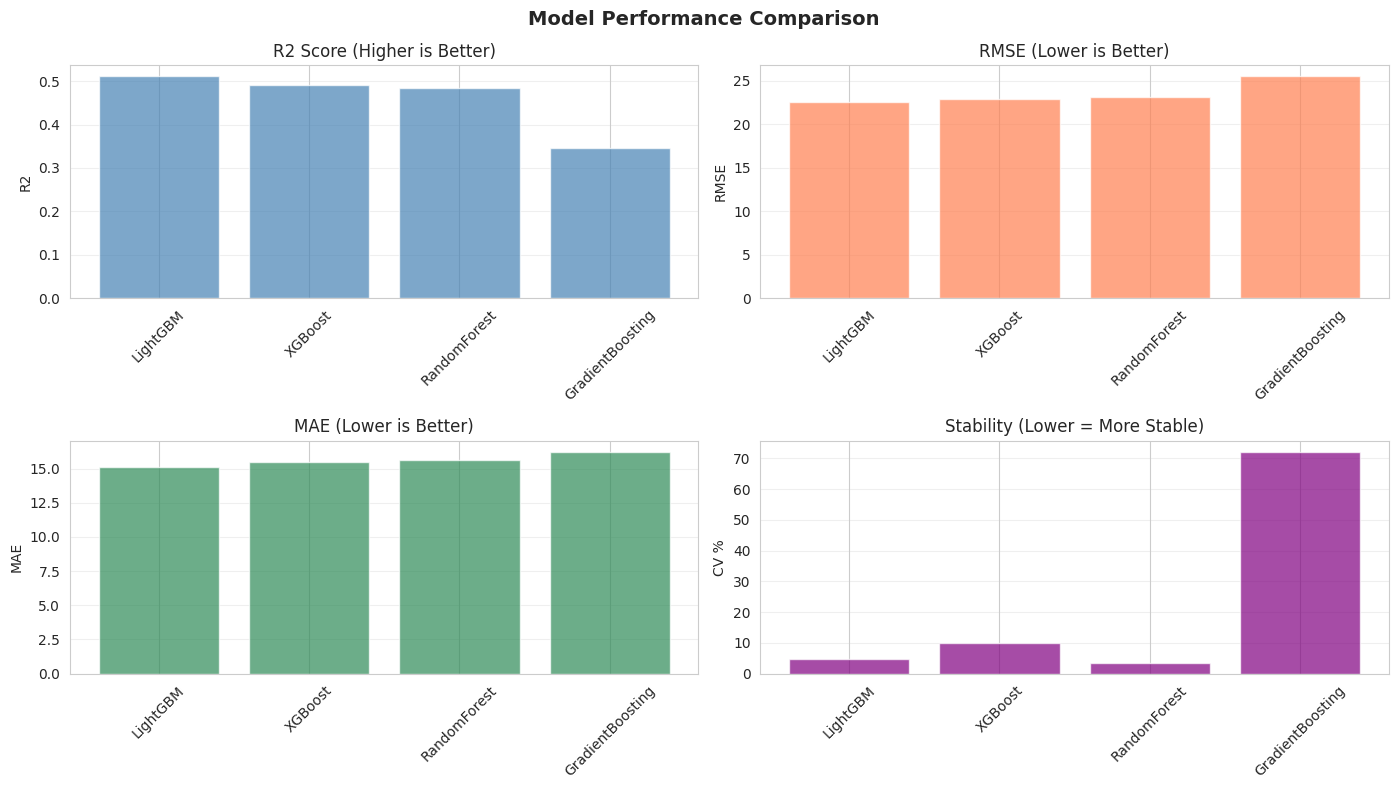

In [33]:
# Model comparison plots
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# R² Score
axes[0, 0].bar(summary_df['Model'], summary_df['Mean R2'], color='steelblue', alpha=0.7)
axes[0, 0].set_title('R2 Score (Higher is Better)')
axes[0, 0].set_ylabel('R2')
axes[0, 0].grid(axis='y', alpha=0.3)

# rmse
axes[0, 1].bar(summary_df['Model'], summary_df['Mean RMSE'], color='coral', alpha=0.7)
axes[0, 1].set_title('RMSE (Lower is Better)')
axes[0, 1].set_ylabel('RMSE')
axes[0, 1].grid(axis='y', alpha=0.3)

# mae
axes[1, 0].bar(summary_df['Model'], summary_df['Mean MAE'], color='seagreen', alpha=0.7)
axes[1, 0].set_title('MAE (Lower is Better)')
axes[1, 0].set_ylabel('MAE')
axes[1, 0].grid(axis='y', alpha=0.3)

cv = (summary_df['Std R2'] / summary_df['Mean R2']) * 100
axes[1, 1].bar(summary_df['Model'], cv, color='purple', alpha=0.7)
axes[1, 1].set_title('Stability (Lower = More Stable)')
axes[1, 1].set_ylabel('CV %')
axes[1, 1].grid(axis='y', alpha=0.3)

for ax in axes.flat:
    ax.tick_params(axis='x', rotation=45)

plt.suptitle('Model Performance Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

 * LightGBM shows the highest performance (R2 Score).
 * GradientBoosting exhibits the highest standard deviation which indicates slightly less stability across different runs.
 * Whereas, RandomForest shows the best stability.

# 9. Hyperparameter Tuning

In [34]:
# n_estimators_lgb = 200      
# n_iter_lgb = 25           
# cv_splits = 3

# param_grid_lgb = {
#     "learning_rate": [0.03, 0.05, 0.1],
#     "num_leaves": [31, 63, 127],
#     "max_depth": [7, 9, 11],
#     "min_child_samples": [20, 40],
#     "subsample": [0.85, 1.0],
#     "colsample_bytree": [0.85, 1.0],
#     "reg_alpha": [0.0, 0.1],
#     "reg_lambda": [0.0, 0.1],
#     "min_split_gain": [0.0, 0.1],
#     'bagging_freq': [0, 5]
# }

# X_tune = X.drop(columns=['show_date', 'book_theater_id'])
# X_tune_proc = preprocessor.fit_transform(X_tune)

# lgb_model = LGBMRegressor(
#     n_estimators=n_estimators_lgb,
#     callbacks=[lgb.early_stopping(stopping_rounds=30)],
#     force_col_wise= True,
#     random_state=42,
#     n_jobs=-1,
#     verbose=-1
# )

# tscv = TimeSeriesSplit(n_splits=cv_splits)

# lgb_search = RandomizedSearchCV(
#     estimator=lgb_model,
#     param_distributions=param_grid_lgb,
#     cv=tscv,
#     scoring='r2',
#     n_iter=n_iter_lgb,
#     n_jobs=-1,
#     random_state=42,
#     verbose=2,
#     return_train_score=False
# )

# lgb_search.fit(X_tune_proc, y, eval_set= [(X_tune_proc, y)], eval_metric= 'rmse')

# print(f"\nBest CV R²: {lgb_search.best_score_:.4f}")
# print(f"Best Parameters: {lgb_search.best_params_}")
# print(f"Trees used during HPT: {lgb_search.best_estimator_.get_params()['n_estimators']}")


In [35]:
# Best CV R²: 0.5694
# Best Parameters: {'subsample': 0.85, 'reg_lambda': 0.1, 'reg_alpha': 0.0, 'num_leaves': 31, 'min_split_gain': 0.1, 'min_child_samples': 40, 'max_depth': 11, 'learning_rate': 0.03, 'colsample_bytree': 1.0, 'bagging_freq': 0}
# Trees used during HPT: 200

In [36]:
best_params_lgb = {
    'learning_rate': 0.03,
    'num_leaves': 31,
    'max_depth': 11,
    'min_child_samples': 40,
    'subsample': 0.85,
    'colsample_bytree': 1.0,
    'reg_alpha': 0.0,
    'reg_lambda': 0.1,
    'min_split_gain': 0.1,
    'bagging_freq': 0
}

* Hyperparameter tuning is performed for systematic search for better parameters.
* RandomizedSearchCV tests random sample of combinations.
*  Analysis of Best Parameters:
 b) learning_rate: 0.03 (initially 0.05) - slower learning.
 c) max_depth: 11 (initially 7) -four levels deeper.
 d) num_leaves: 100 
 e) min_child_samples: 5 
 f) subsample: 1.0 - Uses entire data.
 g) colsample_bytree: 0.8 
 h)  reg_alpha: 0.1 - L1 regularization.
 i)  reg_lambda: 0.01- L2 regularization.

In [37]:
tscv = TimeSeriesSplit(n_splits=3)
tuned_results = {'r2': [], 'rmse': [], 'mae': []}

for fold, (train_idx, val_idx) in enumerate(tscv.split(X), 1):
    X_train_proc = preprocessor.fit_transform(
        X.iloc[train_idx].drop(columns=['show_date', 'book_theater_id'])
    )
    X_val_proc = preprocessor.transform(
        X.iloc[val_idx].drop(columns=['show_date', 'book_theater_id'])
    )
    
    fold_model = LGBMRegressor(
        **best_params_lgb,
        n_estimators=800,
        random_state=42,
        n_jobs=-1,
        verbose=-1,
        force_col_wise=True
    )
    
    fold_model.fit(
        X_train_proc, y.iloc[train_idx],
        eval_set=[(X_val_proc, y.iloc[val_idx])],
        callbacks=[lgb.early_stopping(50, verbose=False)]
    )
    
    pred = fold_model.predict(X_val_proc).clip(0)
    tuned_results['r2'].append(r2_score(y.iloc[val_idx], pred))
    tuned_results['rmse'].append(np.sqrt(mean_squared_error(y.iloc[val_idx], pred)))
    tuned_results['mae'].append(mean_absolute_error(y.iloc[val_idx], pred))
    
    print(f"Fold {fold}: R²={tuned_results['r2'][-1]:.4f}, RMSE={tuned_results['rmse'][-1]:.2f}")

print(f"\nTuned LightGBM  Average CV Results:")
print(f"R²   = {np.mean(tuned_results['r2']):.4f}")
print(f"RMSE = {np.mean(tuned_results['rmse']):.2f}")
print(f"MAE  = {np.mean(tuned_results['mae']):.2f}")

Fold 1: R²=0.4831, RMSE=22.48
Fold 2: R²=0.5381, RMSE=22.40
Fold 3: R²=0.5195, RMSE=22.40

Tuned LightGBM  Average CV Results:
R²   = 0.5136
RMSE = 22.43
MAE  = 15.05


In [38]:
print("\nImprovement over Baseline:")
baseline_r2 = np.mean(results['LightGBM']['r2'])  
baseline_rmse = np.mean(results['LightGBM']['rmse'])
baseline_mae = np.mean(results['LightGBM']['mae'])

tuned_r2 = np.mean(tuned_results['r2'])
tuned_rmse = np.mean(tuned_results['rmse'])
tuned_mae = np.mean(tuned_results['mae'])

print(f"R² improvement: {baseline_r2:.4f} to {tuned_r2:.4f}")
print(f"RMSE improvement: {baseline_rmse:.2f} to {tuned_rmse:.2f}")
print(f"MAE improvement: {baseline_mae:.2f} to {tuned_mae:.2f}")


Improvement over Baseline:
R² improvement: 0.5111 to 0.5136
RMSE improvement: 22.48 to 22.43
MAE improvement: 15.10 to 15.05


# 10. Ensembling

In [39]:
lgb_model = LGBMRegressor(
    **best_params_lgb, 
    n_estimators=700, 
    random_state=42, 
    n_jobs=-1, 
    verbose=-1
)
xgb_model = XGBRegressor(
    n_estimators=700, 
    learning_rate=0.05, 
    max_depth=6, 
    random_state=42, 
    n_jobs=-1, 
    verbosity=0
)
rf_model = RandomForestRegressor(
    n_estimators=300, 
    max_depth=15, 
    random_state=42, 
    n_jobs=-1
)
gb_model = GradientBoostingRegressor(
    n_estimators=300, 
    learning_rate=0.05, 
    max_depth=6, 
    random_state=42
)

sub_start = pd.to_datetime(sample_submission['ID'].str.split('_').str[-1]).min()
X_proc = preprocessor.fit_transform(
    X[data['show_date'] < sub_start].drop(columns=['show_date', 'book_theater_id'])
)
y_proc = y[data['show_date'] < sub_start]

for model in [lgb_model, xgb_model, rf_model, gb_model]:
    model.fit(X_proc, y_proc)

def ensemble_predict(X):
    lgb_pred = lgb_model.predict(X)
    xgb_pred = xgb_model.predict(X)
    rf_pred = rf_model.predict(X)
    gb_pred = gb_model.predict(X)
    
    ensemble = 0.55*lgb_pred + 0.30*xgb_pred + 0.10*rf_pred + 0.05*gb_pred
    return ensemble.clip(0)

# 11. Submission

In [40]:
submission = sample_submission[['ID']].copy()
submission['book_theater_id'] = submission['ID'].str.rsplit('_', n=1).str[0]
submission['show_date'] = pd.to_datetime(submission['ID'].str.rsplit('_', n=1).str[1])

future_dates = sorted(submission['show_date'].unique())
history = base[base['show_date'] < sub_start].copy()
predictions = []

for curr_date in future_dates:
  
    today = pd.DataFrame({
        'book_theater_id': base['book_theater_id'].unique(), 
        'show_date': curr_date
    })
    
    today = today.merge(booknow_theaters, on='book_theater_id', how='left')
    today = today.merge(online, on=['book_theater_id', 'show_date'], how='left')
    today = today.merge(onsite[['book_theater_id', 'show_date', 'onsite_tickets_sum', 'onsite_sales_count']], 
                        on=['book_theater_id', 'show_date'], how='left')
    today[booking_columns] = today[booking_columns].fillna(0)
    
    temp = pd.concat([history, today], ignore_index=True)
    temp = date_and_lag_features(temp)
    temp['theater_encoded'] = le.transform(temp['book_theater_id'])
    
    today_proc = preprocessor.transform(temp[temp['show_date'] == curr_date][all_features].fillna(0))
    today['audience_count'] = ensemble_predict(today_proc)
    
    predictions.append(today[['book_theater_id', 'show_date', 'audience_count']])
    history = pd.concat([history, today], ignore_index=True)

final_pred = pd.concat(predictions, ignore_index=True)
final_sub = submission.merge(final_pred, on=['book_theater_id', 'show_date'], how='left')
final_sub['audience_count'] = final_sub['audience_count'].fillna(final_pred['audience_count'].median()).round().astype(int).clip(0)

final_sub[['ID', 'audience_count']].to_csv('submission.csv', index=False)

print(f"Predicted {len(future_dates)} days for {len(predictions[0])} theatres")
print(f"Stats: mean={final_sub['audience_count'].mean():.1f}, median={final_sub['audience_count'].median():.0f}")

Predicted 53 days for 826 theatres
Stats: mean=41.4, median=38


In [41]:
print(f"Final Predictions Statistics: {final_sub.describe()}")
print(f"\n{final_sub.head(10)}")

Final Predictions Statistics:                            show_date  audience_count
count                          38062    38062.000000
mean   2024-03-27 01:00:41.048815104       41.426094
min              2024-03-01 00:00:00        4.000000
25%              2024-03-14 00:00:00       24.000000
50%              2024-03-27 00:00:00       38.000000
75%              2024-04-09 00:00:00       55.000000
max              2024-04-22 00:00:00      163.000000
std                              NaN       22.021229

                      ID book_theater_id  show_date  audience_count
0  book_00001_2024-03-01      book_00001 2024-03-01              28
1  book_00001_2024-03-02      book_00001 2024-03-02              43
2  book_00001_2024-03-03      book_00001 2024-03-03              48
3  book_00001_2024-03-04      book_00001 2024-03-04              47
4  book_00001_2024-03-06      book_00001 2024-03-06              30
5  book_00001_2024-03-07      book_00001 2024-03-07              32
6  book_00001_20

* Observations-
* March 2-3 (Saturday-Sunday): 43-48 people denotes weekend spike.
* March 4 (Monday): 47 people shows up on Monday.
* March 9-10 (Saturday-Sunday): 46-48 people shows another weekend spike.
* March 11 (Monday): 48 people shows up on this  Monday which is consistent with previous weekend pattern.